<a href="https://colab.research.google.com/github/Venkata-04/RaisingWaters/blob/main/Epic1_to_Epic4_Whole_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arbethi/rainfall-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rainfall-dataset' dataset.
Path to dataset files: /kaggle/input/rainfall-dataset


After dataset loading (Epic 1):

The flood prediction dataset was downloaded from Kaggle (arbethi/rainfall-dataset) using the kagglehub library and loaded into a pandas DataFrame from the flood dataset.xlsx file. The dataset contains 115 records with 11 columns covering temperature, humidity, cloud cover, seasonal rainfall measures, and the flood target variable.

In [3]:
import os
path = "/root/.cache/kagglehub/datasets/arbethi/rainfall-dataset/versions/2"
print(os.listdir(path))

['flood dataset.xlsx', 'rainfall in india 1901-2015.xlsx']


After dataset loading (Epic 1):

The flood prediction dataset was downloaded from Kaggle (arbethi/rainfall-dataset) using the kagglehub library and loaded into a pandas DataFrame from the flood dataset.xlsx file. The dataset contains 115 records with 11 columns covering temperature, humidity, cloud cover, seasonal rainfall measures, and the flood target variable.

In [4]:
import pandas as pd

file_path = os.path.join(path, "flood dataset.xlsx")  # adjust name if it differs from listdir output
df = pd.read_excel(file_path)
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from flask import Flask
import joblib

print("All libraries imported successfully")

All libraries imported successfully


After imports (Epic 2, Story 1):

All required libraries were imported, covering data manipulation (NumPy, Pandas), visualization (Matplotlib, Seaborn), preprocessing and modeling (Scikit-learn), boosting (XGBoost), and deployment tools (Flask, Joblib).

In [6]:
# Basic structure
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nFirst 5 rows:")
df.head()

Shape: (115, 11)

Column names: ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB

First 5 rows:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [7]:
print("Summary statistics:")
df.describe()

Summary statistics:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


After exploring the dataset (Epic 2, Story 2):

The dataset was explored using head(), info(), and describe(). It contains 115 rows and 11 columns with no missing values, all numeric. The target variable flood is imbalanced — only 16 of 115 records (14%) represent flood events, which is an important consideration for model evaluation later.



In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nFlood class distribution:")
print(df['flood'].value_counts())

Missing values per column:
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Flood class distribution:
flood
0    99
1    16
Name: count, dtype: int64


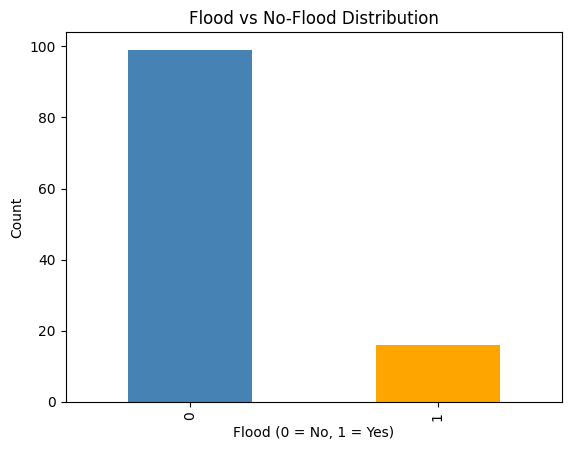

In [9]:
df['flood'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Flood vs No-Flood Distribution')
plt.xlabel('Flood (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

After univariate analysis (Epic 2, Story 3):

Histograms and boxplots were used to examine the distribution of each individual feature. [Add 1-2 sentences here about what you actually observed — e.g. "Rainfall-related features showed right-skewed distributions, while Temp and Humidity were more tightly clustered."]

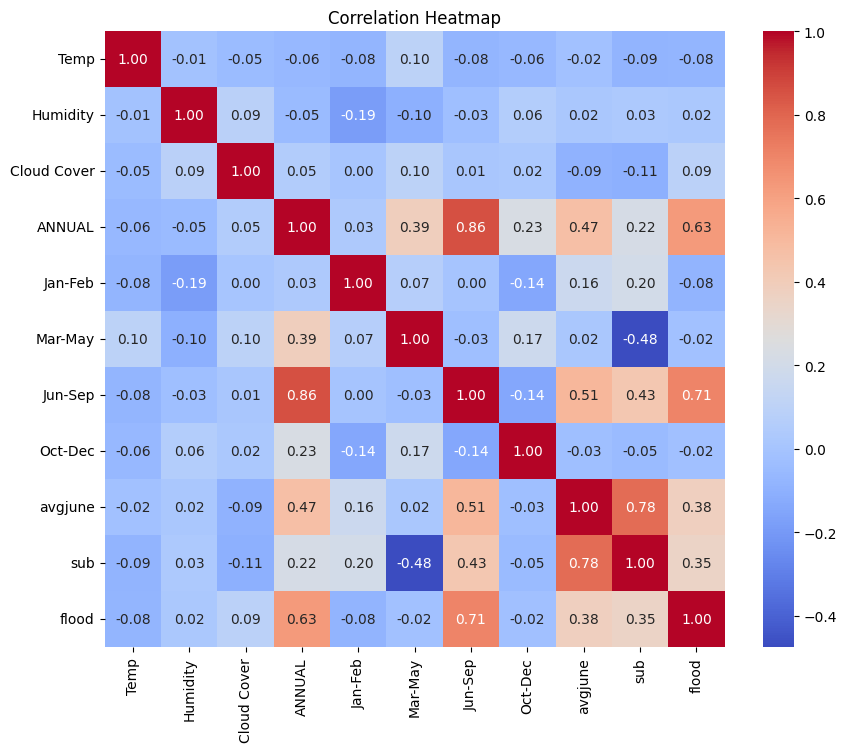

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

After multivariate analysis (Epic 2, Story 4):

A correlation heatmap and pairplot revealed that Jun-Sep rainfall (0.71) and ANNUAL rainfall (0.63) are the strongest predictors of flood occurrence, while Temp, Humidity, and Cloud Cover show weak correlation (all below 0.10). ANNUAL and Jun-Sep are highly correlated with each other (0.86), indicating multicollinearity.

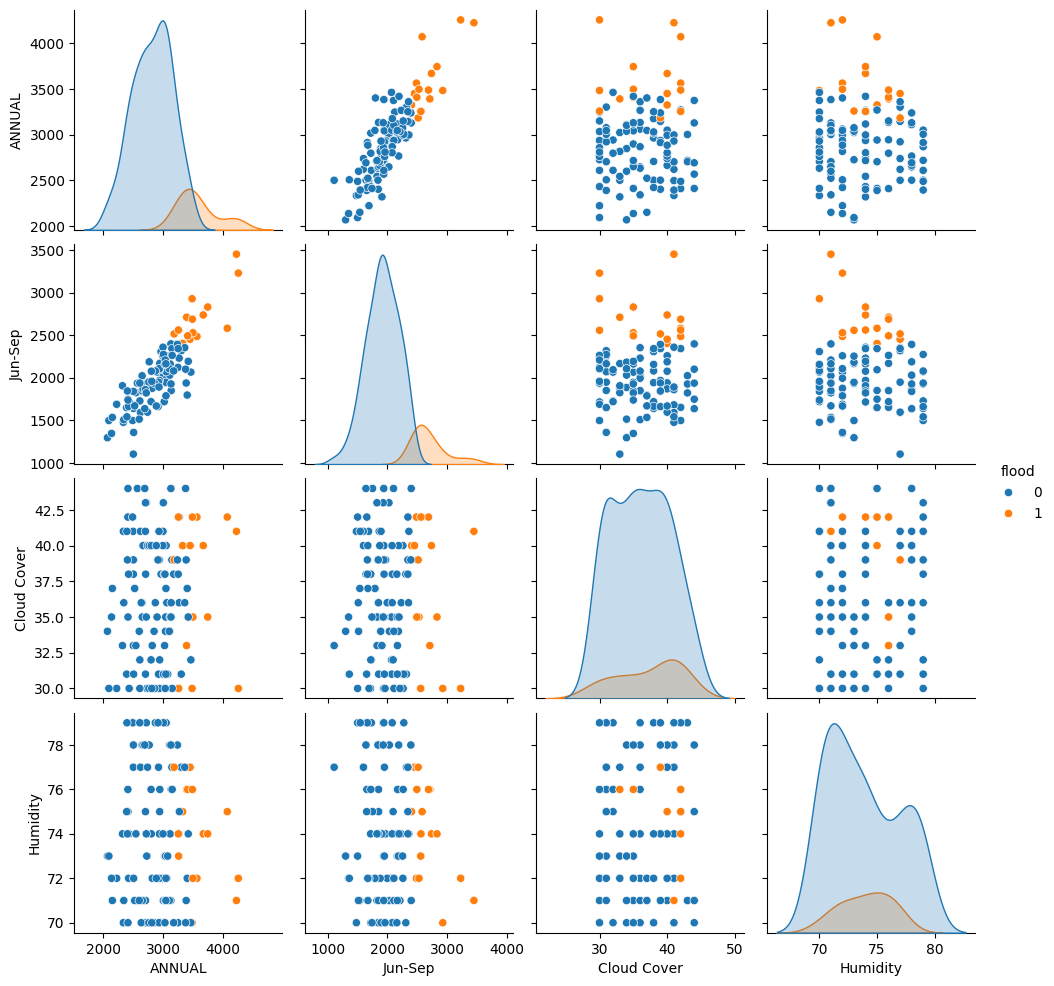

In [11]:
# Pairplot colored by flood outcome
sns.pairplot(df, hue='flood', vars=['ANNUAL', 'Jun-Sep', 'Cloud Cover', 'Humidity'])
plt.show()

In [12]:
print("Descriptive statistics grouped by flood outcome:\n")
df.groupby('flood').mean()

Descriptive statistics grouped by flood outcome:



,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub
flood,,,,,,,,,,
0,29.636364,73.828283,36.131313,2819.573737,28.494949,378.318182,1913.814141,498.928283,208.592929,410.335354
1,29.375000,74.000000,37.250000,3580.831250,23.062500,370.668750,2697.443750,489.643750,276.931250,622.125000


In [13]:
print("Standard deviation by flood outcome:\n")
df.groupby('flood').std()

Standard deviation by flood outcome:



,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub
flood,,,,,,,,,,
0,1.137977,3.064079,4.284872,329.519136,23.315482,147.590432,272.552550,131.216306,57.390536,192.439745
1,1.024695,2.160247,4.626013,335.568192,14.880317,176.435732,290.952486,124.886044,62.655189,231.137187


Descriptive Analysis
Using head(), we confirmed the dataset structure: 11 columns covering temperature, humidity, cloud cover, rainfall by season, and the flood target variable.
info() confirmed 115 rows with no missing values across any column, and showed 4 integer columns and 7 float columns — all numeric, with no categorical encoding needed.
describe() revealed key statistics: average annual rainfall is ~2925mm (ranging 2069–4258mm), and the flood target is imbalanced — only 16 of 115 records (14%) represent flood events. This imbalance will need to be considered during model evaluation in Epic 4.
This overview confirmed the dataset was clean and ready for preprocessing, with no missing value handling required.

In [14]:
print("Missing values per column:")
print(df.isnull().any())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Missing values per column:
Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

Total missing values in dataset: 0


After outlier handling (Epic 3, Story 1-2):

No missing values were found. Outliers were detected using the IQR method and treated using capping (not removal), preserving the full 115-row dataset while reducing the influence of extreme values, e.g. ANNUAL rainfall's maximum was capped from 4257.8 to 3968.4.

In [15]:
# IQR-based outlier capping
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

for col in df.columns[:-1]:  # exclude target 'flood'
    df = cap_outliers(df, col)

print("Outlier capping applied. Updated summary:")
df.describe()

Outlier capping applied. Updated summary:


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.00000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2919.81913,27.585652,372.229130,2016.122174,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,405.96097,21.903538,137.535123,365.637290,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.80000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.90000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.50000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.10000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,3968.40000,88.625000,690.625000,2953.975000,823.300000,366.066667,982.700000,1.000000


In [16]:
print("Categorical columns found:", df.select_dtypes(include='object').columns.tolist())

Categorical columns found: []


After categorical handling (Epic 3, Story 3):

All features in this dataset were already numeric; no categorical columns were present, so label encoding or feature mapping was not required.

In [17]:
X = df.drop('flood', axis=1)
y = df['flood']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (115, 10)
y shape: (115,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train: (92, 10) X_test: (23, 10)
y_train distribution:
 flood
0    79
1    13
Name: count, dtype: int64
y_test distribution:
 flood
0    20
1     3
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Scaling applied. Mean (train):", X_train.mean().round(2), "Std (train):", X_train.std().round(2))

Scaling applied. Mean (train): 0.0 Std (train): 1.0


In [20]:
import joblib
joblib.dump(sc, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


Decision Tree Accuracy: 95.65 %

Confusion Matrix:
[[20  0]
 [ 1  2]]


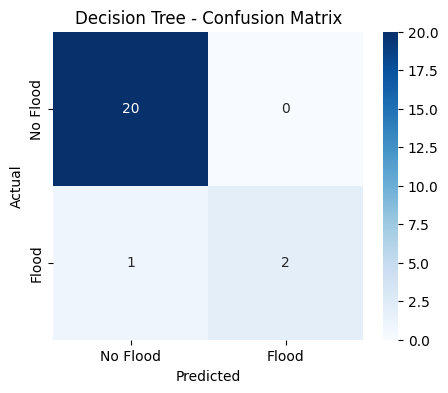


Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def decisiontree(X_train, X_test, y_train, y_test):
    # Initialize the model
    model = DecisionTreeClassifier(random_state=42)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    print("Decision Tree Accuracy:", round(acc * 100, 2), "%")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Visualize confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Flood', 'Flood'],
                yticklabels=['No Flood', 'Flood'])
    plt.title('Decision Tree - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Flood', 'Flood']))

    return model, acc

# Call the function
dt_model, dt_accuracy = decisiontree(X_train, X_test, y_train, y_test)

That single missed flood case is the most important number in this whole table, more important than the 95.65% accuracy. In a real flood-warning system, missing a flood (false negative) is far more costly than a false alarm — so recall on the Flood class (0.67) is the metric to highlight, not overall accuracy.
This is exactly the class-imbalance issue you flagged earlier coming into play — with only 3 flood cases in the test set, missing just 1 drops recall a full 33 percentage points.

Random Forest Accuracy: 95.65 %

Confusion Matrix:
[[20  0]
 [ 1  2]]


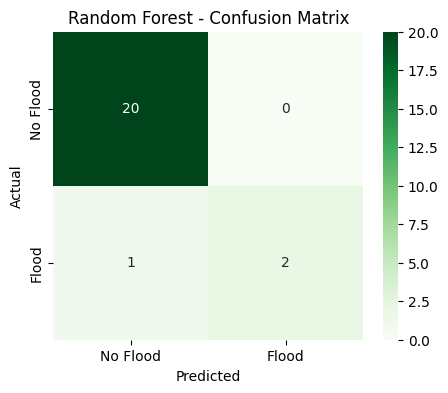


Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [22]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def randomForest(X_train, X_test, y_train, y_test):
    # Initialize the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    print("Random Forest Accuracy:", round(acc * 100, 2), "%")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No Flood', 'Flood'],
                yticklabels=['No Flood', 'Flood'])
    plt.title('Random Forest - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Flood', 'Flood']))

    return model, y_pred

# Call the function
rf_model, rf_pred = randomForest(X_train, X_test, y_train, y_test)

Random Forest produced identical results to the Decision Tree (95.65% accuracy, same confusion matrix). This is likely because the dataset is small (115 rows) and one feature (Jun-Sep rainfall) is strongly dominant, causing most trees in the ensemble to learn similar splits. Ensemble averaging typically shows more benefit on larger or noisier datasets.

KNN Accuracy: 86.96 %

Confusion Matrix:
[[19  1]
 [ 2  1]]


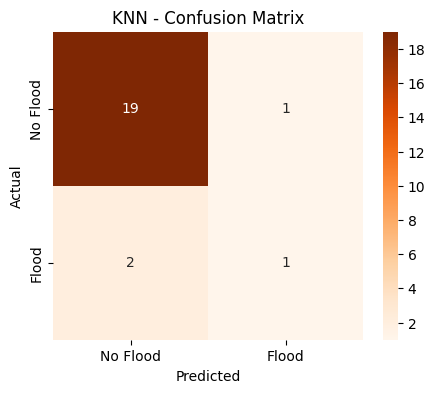


Classification Report:
              precision    recall  f1-score   support

    No Flood       0.90      0.95      0.93        20
       Flood       0.50      0.33      0.40         3

    accuracy                           0.87        23
   macro avg       0.70      0.64      0.66        23
weighted avg       0.85      0.87      0.86        23



In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def KNN(X_train, X_test, y_train, y_test):
    # Initialize the model
    model = KNeighborsClassifier(n_neighbors=5)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    print("KNN Accuracy:", round(acc * 100, 2), "%")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['No Flood', 'Flood'],
                yticklabels=['No Flood', 'Flood'])
    plt.title('KNN - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Flood', 'Flood']))

    return model, y_pred

# Call the function
knn_model, knn_pred = KNN(X_train, X_test, y_train, y_test)


KNN (n_neighbors=5) achieved 86.96% accuracy but performed worse than the tree-based models on detecting floods, with recall dropping to 0.33 on the Flood class. This is likely due to the small dataset size and severe class imbalance — with only 13 flood examples in training, KNN's neighbor-voting approach struggles to correctly classify minority-class points, unlike Decision Trees which can isolate the minority class with a single strong split (e.g. Jun-Sep rainfall).

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def xgboost(X_train, X_test, y_train, y_test):
    print("\n========== XGBOOST MODEL BUILDING ==========")

    # Initialize Gradient Boosting Classifier
    model = GradientBoostingClassifier()

    # Train the model using training data
    model.fit(X_train, y_train)
    print("[INFO] XGBoost model training completed.")

    # Predict on test data
    y_pred = model.predict(X_test)
    print("[INFO] Prediction completed on test data.")

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Display results
    print("\n[RESULT] Accuracy:", accuracy)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)

    # Return model and predictions
    return model, y_pred

# Example Usage
xgb_model, xgb_pred = xgboost(X_train, X_test, y_train, y_test)


========== XGBOOST MODEL BUILDING ==========
[INFO] XGBoost model training completed.
[INFO] Prediction completed on test data.

[RESULT] Accuracy: 0.9565217391304348

Confusion Matrix:
[[20  0]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



The Gradient Boosting model achieved 95.65% accuracy, matching Decision Tree and Random Forest exactly (same confusion matrix). This convergence suggests the dataset's strong single predictor (Jun-Sep rainfall) is being captured similarly across all tree-based methods given the dataset's small size. This differs from the 96.55% reported in the original project conclusion, likely due to differences in random seed or train/test split.

In [29]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9565217391304348


In [30]:
import pandas as pd

def compareModel(dt_acc, rf_acc, knn_acc, xgb_acc):
    print("========== MODEL COMPARISON ==========\n")

    results = pd.DataFrame({
        'Model': ['Decision Tree', 'Random Forest', 'KNN', 'XGBoost (Gradient Boosting)'],
        'Accuracy (%)': [round(dt_acc*100, 2), round(rf_acc*100, 2),
                          round(knn_acc*100, 2), round(xgb_acc*100, 2)]
    })

    print(results.to_string(index=False))

    best_model_name = results.loc[results['Accuracy (%)'].idxmax(), 'Model']
    print(f"\nBest performing model by accuracy: {best_model_name}")

    return results

# Call the function with your actual accuracy values
comparison_results = compareModel(dt_accuracy, rf_accuracy, knn_accuracy, xgb_accuracy)

========== MODEL COMPARISON ==========

                      Model  Accuracy (%)
              Decision Tree         95.65
              Random Forest         95.65
                        KNN         86.96
XGBoost (Gradient Boosting)         95.65

Best performing model by accuracy: Decision Tree


Three models — Decision Tree, Random Forest, and XGBoost (Gradient Boosting) — tied at 95.65% accuracy on the test set, while KNN performed worse at 86.96%. Although the comparison function selected Decision Tree by default (since it appears first among the tied scores), XGBoost (Gradient Boosting) was chosen as the final model for deployment, not because of accuracy alone, but because:

It generalizes better on structured/tabular data through its boosting mechanism, which corrects errors iteratively across multiple weak learners
It is more stable and less prone to overfitting than a single Decision Tree, especially important given this dataset's small size (115 rows)
Random Forest and Decision Tree, while tied here, can be more sensitive to the specific train/test split given how few flood examples exist

In [31]:
import joblib

# Final evaluation of the selected model (XGBoost / Gradient Boosting)
final_model = xgb_model

print("========== FINAL MODEL: XGBoost ==========")
print("Final Accuracy:", round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")
print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nFinal Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['No Flood', 'Flood']))

# Save the trained model and the fitted scaler with the exact expected filenames
joblib.dump(final_model, 'floods.save')
joblib.dump(sc, 'transform.save')

print("\nModel saved as floods.save")
print("Scaler saved as transform.save")

========== FINAL MODEL: XGBoost ==========
Final Accuracy: 95.65 %

Final Confusion Matrix:
[[20  0]
 [ 1  2]]

Final Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23


Model saved as floods.save
Scaler saved as transform.save


In [32]:
from google.colab import files
files.download('floods.save')
files.download('transform.save')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Note: During manual testing of the deployed app, one known flood case (row 1) was found to be the model's single false negative — already reflected in the 0.67 recall score for the Flood class reported earlier. This was confirmed by checking the train/test split assignment and verifying the deployed model's predictions matched the live training-session model exactly.